## <font color="green">Анализа на влијанието на гејмерството врз академскиот успех кај студентите</font>
Python код за реализација на истражувањето врз симулиран датасет.

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np 
import warnings 

# опции за подобра прегледност
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)  
pd.set_option('display.max_colwidth', 50)  

warnings.simplefilter(action="ignore")

df = pd.read_csv('Gaming_Academic_Performance.csv') 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [ ]:
df.describe() 

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [ ]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

## Прочисутвање на target колоната од outliers
При анализа на датасетот, забележавме дека постојат вредности кои отскокнуваат од пропишаните за таргетот. Имено, за одредени студенти се забележани поени над 100, што укажува на невалидни инстанци! Со цел да работиме со валидните инстанци, извршивме прочистување...

In [ ]:
import matplotlib.pyplot as plt 

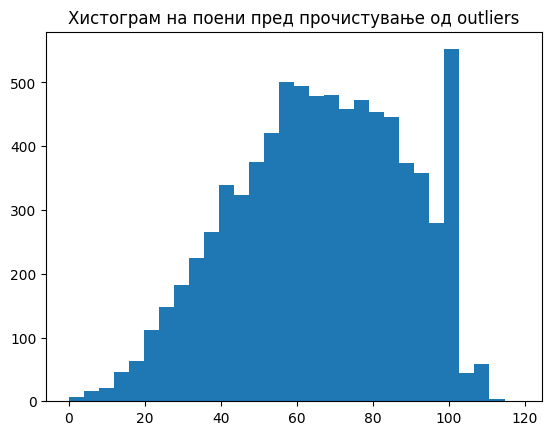

In [ ]:

plt.figure()
plt.hist(df['grades'], bins=30)
plt.title("Хистограм на поени пред прочистување од outliers")
plt.show()

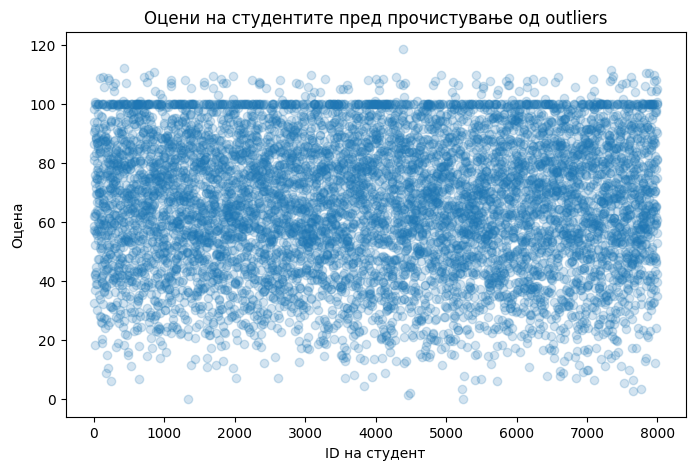

In [ ]:

plt.figure(figsize=(8,5))

plt.scatter(
    df["student_id"],
    df["grades"],
    alpha=0.2
)

plt.xlabel("ID на студент")
plt.ylabel("Оцена")
plt.title("Оцени на студентите пред прочистување од outliers")
plt.show()

In [ ]:
df = df[df["grades"] <= 100]  

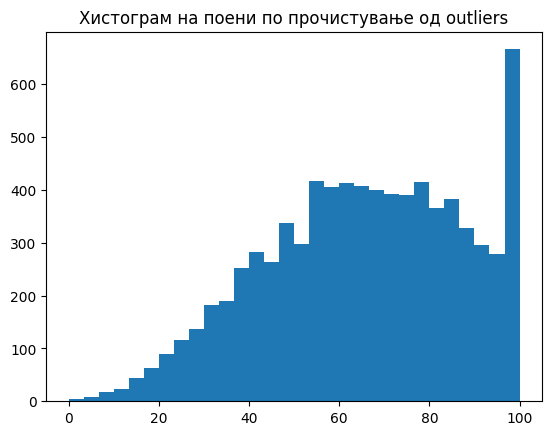

In [ ]:

plt.figure()
plt.hist(df['grades'], bins=30)
plt.title("Хистограм на поени по прочистување од outliers")
plt.show()

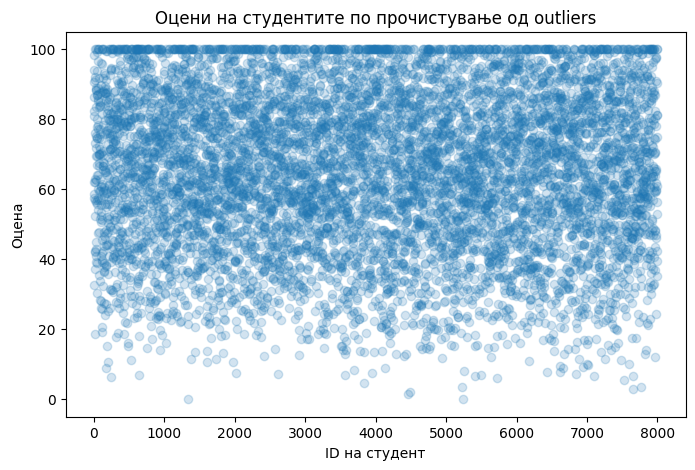

In [ ]:

plt.figure(figsize=(8,5))

plt.scatter(
    df["student_id"],
    df["grades"],
    alpha=0.2
)

plt.xlabel("ID на студент")
plt.ylabel("Оцена")
plt.title("Оцени на студентите по прочистување од outliers")
plt.show()

## Експлоративна анализа и визуелизација на трендови

Во оваа секција ќе разгледаме некои од поврзаностите на наведените features во датасетот...

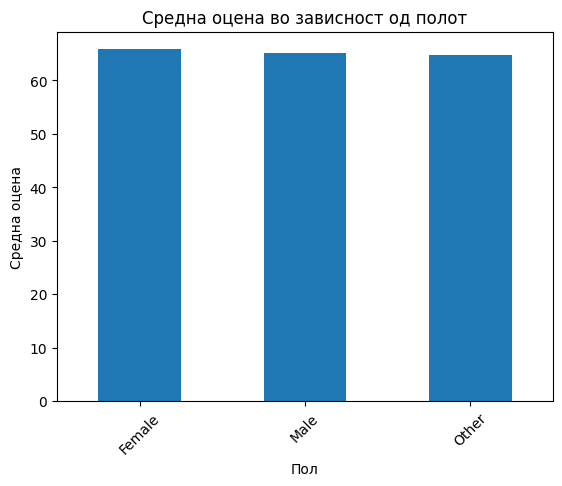

In [ ]:

avg_boxes = df.groupby('gender')['grades'].mean()

plt.figure()
avg_boxes.plot(kind='bar')
plt.title("Средна оцена во зависност од полот")
plt.xlabel("Пол")
plt.ylabel("Средна оцена")
plt.xticks(rotation=45)
plt.show()

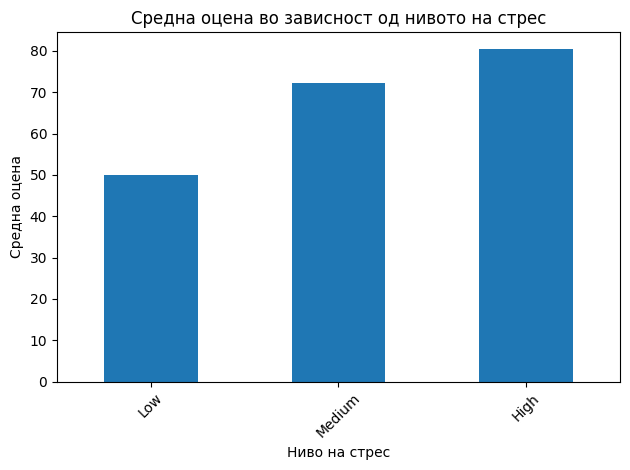

In [ ]:

stress_order = ["Low", "Medium", "High"]
df["stress_level"] = pd.Categorical(
    df["stress_level"], categories=stress_order, ordered=True
)

avg_boxes = df.groupby("stress_level")["grades"].mean()

plt.figure()
avg_boxes.plot(kind="bar")
plt.title("Средна оцена во зависност од нивото на стрес")
plt.xlabel("Ниво на стрес")
plt.ylabel("Средна оцена")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

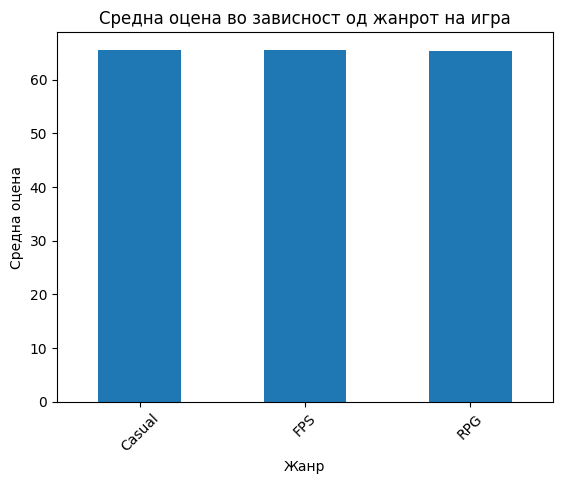

In [ ]:

avg_boxes = df.groupby('gaming_genre')['grades'].mean()

plt.figure()
avg_boxes.plot(kind='bar')
plt.title("Средна оцена во зависност од жанрот на игра")
plt.xlabel("Жанр")
plt.ylabel("Средна оцена")
plt.xticks(rotation=45)
plt.show()

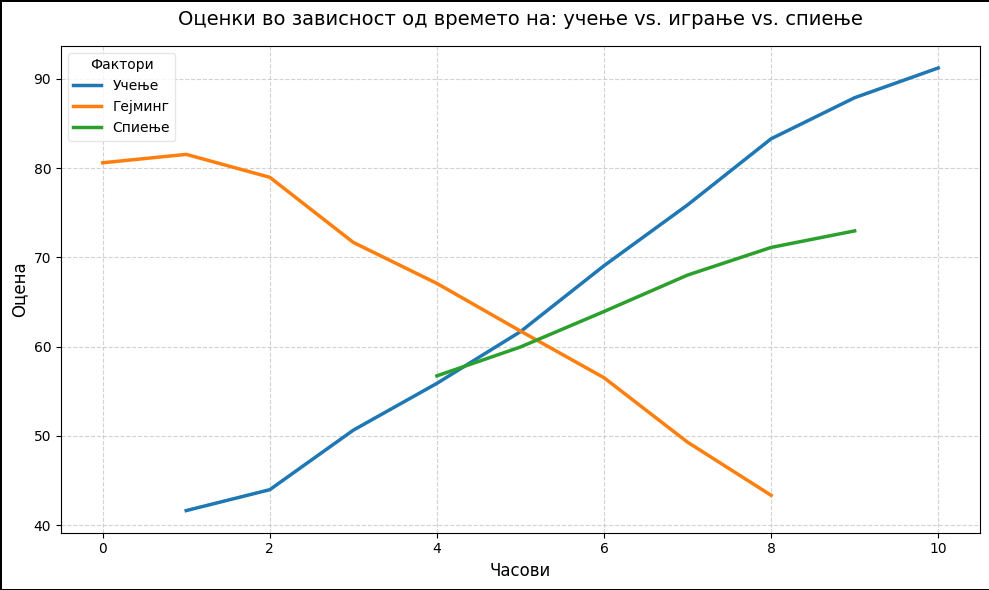

In [ ]:


df['study_hours_round'] = df['study_hours'].round()
df['gaming_hours_round'] = df['gaming_hours'].round()
df['sleep_hours_round'] = df['sleep_hours'].round()


study_trend = df.groupby('study_hours_round')['grades'].mean().reset_index()
gaming_trend = df.groupby('gaming_hours_round')['grades'].mean().reset_index()
sleep_trend = df.groupby('sleep_hours_round')['grades'].mean().reset_index()


study_trend.columns = ['Hours', 'Grades']
study_trend['Factor'] = 'Учење'

gaming_trend.columns = ['Hours', 'Grades']
gaming_trend['Factor'] = 'Гејминг'

sleep_trend.columns = ['Hours', 'Grades']
sleep_trend['Factor'] = 'Спиење'


trend_data = pd.concat([study_trend, gaming_trend, sleep_trend])


fig, ax = plt.subplots(figsize=(10, 6), edgecolor='black', linewidth=1)


sns.lineplot(
    data=trend_data, 
    x='Hours', 
    y='Grades', 
    hue='Factor', 
    linewidth=2.5, 
    ax=ax,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c'] 
)

ax.set_title('Оценки во зависност од времето на: учење vs. играње vs. спиење', fontsize=14, pad=15)
ax.set_xlabel('Часови', fontsize=12)
ax.set_ylabel('Оцена', fontsize=12)

ax.grid(True, linestyle='--', alpha=0.7, color='#C0C0C0')

ax.legend(title='Фактори', loc='upper left', frameon=True, facecolor='white', edgecolor='#E0E0E0')

plt.tight_layout()
plt.show()

In [ ]:

df = df.drop(['study_hours_round'], axis=1)
df = df.drop(['gaming_hours_round'], axis=1)
df = df.drop(['sleep_hours_round'], axis=1)

## Кодирање на колони со номинални вредности
Извршивме ординално кодирање на три колони: gender, gaming_genre и stress_level, со цел да можат да се користат за тренирање на моделот.

In [ ]:
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [32]:
mapping_gender = {
    "Male" : 0,
    "Female" : 1,
    "Other" : 2
}
df["gender"] = df["gender"].map(mapping_gender)

In [ ]:
df['gaming_genre'].unique()

array(['FPS', 'Casual', 'RPG'], dtype=object)

In [ ]:
mapping_games = {
    "FPS" : 0, 
    "Casual" : 1,
    "RPG" : 2 
}
df["gaming_genre"] = df["gaming_genre"].map(mapping_games)

In [ ]:
df['stress_level'].unique() 

['Low', 'Medium', 'High']
Categories (3, object): ['Low' < 'Medium' < 'High']

In [36]:
mapping_stress = {
    "Low" : 0,
    "Medium" : 1,
    "High" : 2
}
df["stress_level"] = df["stress_level"].map(mapping_stress)

In [ ]:
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,0,7.23,8.78,6.96,91.44,0,3.25,9.36,235.84,14.69,0,86.459555
1,2,19,0,0.07,8.72,7.63,63.63,1,1.02,3.21,328.71,2.47,1,98.230000
2,3,23,1,1.73,9.56,4.40,83.26,1,3.46,5.56,313.61,4.73,2,90.560000
3,4,20,1,6.62,1.68,7.83,75.04,2,1.46,11.78,241.84,14.54,0,32.670000
4,5,22,1,5.36,5.83,5.55,65.57,0,1.01,8.23,249.31,12.48,0,58.710000


## Поделба на features и target колоните
Се изделува target-от од останатите features за да може при понатамошното тренирање на моделот да се вршат предикции и да се оценува точноста на истите.

In [ ]:
y = pd.DataFrame(df.iloc[:,13])
X = df.drop(['grades'], axis=1)

In [ ]:
X

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level
0,1,22,0,7.23,8.78,6.96,91.44,0,3.25,9.36,235.84,14.69,0
1,2,19,0,0.07,8.72,7.63,63.63,1,1.02,3.21,328.71,2.47,1
2,3,23,1,1.73,9.56,4.40,83.26,1,3.46,5.56,313.61,4.73,2
3,4,20,1,6.62,1.68,7.83,75.04,2,1.46,11.78,241.84,14.54,0
4,5,22,1,5.36,5.83,5.55,65.57,0,1.01,8.23,249.31,12.48,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,24,0,6.33,5.09,4.83,63.74,0,4.11,9.96,231.33,11.14,0
7996,7997,22,1,5.77,6.09,6.23,84.37,0,3.42,11.19,254.13,10.66,0
7997,7998,20,0,2.87,8.51,8.62,67.30,0,2.36,6.40,305.00,6.42,1
7998,7999,22,1,0.98,2.99,7.29,61.13,0,2.02,4.57,325.36,2.14,1


In [ ]:
y

,grades
0,86.459555
1,98.230000
2,90.560000
3,32.670000
4,58.710000
...,...
7995,35.110000
7996,60.800000
7997,90.280000
7998,56.330000


## Вршење стандардизација на нумеричките колони

Откако се осигуравме дека сите вредности се нумерички, извршивме стандардизација со цел да биде урамножетено влијанието на секој feature.

In [41]:
from sklearn.preprocessing import StandardScaler

In [ ]:
standard_scaler = StandardScaler()

X[X.columns] = standard_scaler.fit_transform(X[X.columns])
X.describe()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level
count,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03,7.866000e+03
mean,-5.781177e-17,-3.233846e-16,9.936397e-17,-5.329522e-17,-1.806618e-18,-4.290717e-16,-3.979075e-16,-9.033088e-18,-2.678311e-16,-2.041478e-16,1.065904e-16,2.504424e-16,1.806618e-17
std,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00,1.000064e+00
min,-1.733277e+00,-1.540406e+00,-9.670648e-01,-1.783024e+00,-1.721836e+00,-1.719161e+00,-1.711731e+00,-1.085206e+00,-1.739933e+00,-2.403346e+00,-2.978172e+00,-2.873659e+00,-1.202688e+00
25%,-8.646891e-01,-7.674023e-01,-9.670648e-01,-8.416383e-01,-8.660469e-01,-8.659870e-01,-8.710279e-01,-1.085206e+00,-8.496164e-01,-7.453966e-01,-8.149911e-01,-7.876524e-01,-1.202688e+00
50%,-1.306657e-03,5.601476e-03,7.974751e-01,2.599821e-02,-1.221148e-02,1.059944e-03,-2.168407e-02,1.172494e-01,-4.423276e-03,1.157380e-02,-2.364150e-02,2.291013e-02,3.365805e-01
75%,8.659800e-01,7.786052e-01,7.974751e-01,8.578447e-01,8.416240e-01,8.542341e-01,8.792857e-01,1.319705e+00,8.702735e-01,7.390038e-01,7.987431e-01,7.838059e-01,3.365805e-01
max,1.736737e+00,1.551609e+00,2.562015e+00,1.687522e+00,1.795106e+00,1.749027e+00,1.744398e+00,1.319705e+00,1.731086e+00,2.341565e+00,2.620369e+00,2.623465e+00,1.875849e+00


## Испитување на корелација помеѓу features
Генерално, сакаме features-те да се што е можно помалку корелирани за да добиеме подобра непристрасност, точност и ефикасност во процесот на тренирање. Со други зборови, поголема е веројатноста да се добијат уникатни увиди во релациите помеѓу повеќе <b>неповрзани</b> features. 

In [ ]:
X = X.drop(['student_id'], axis=1)

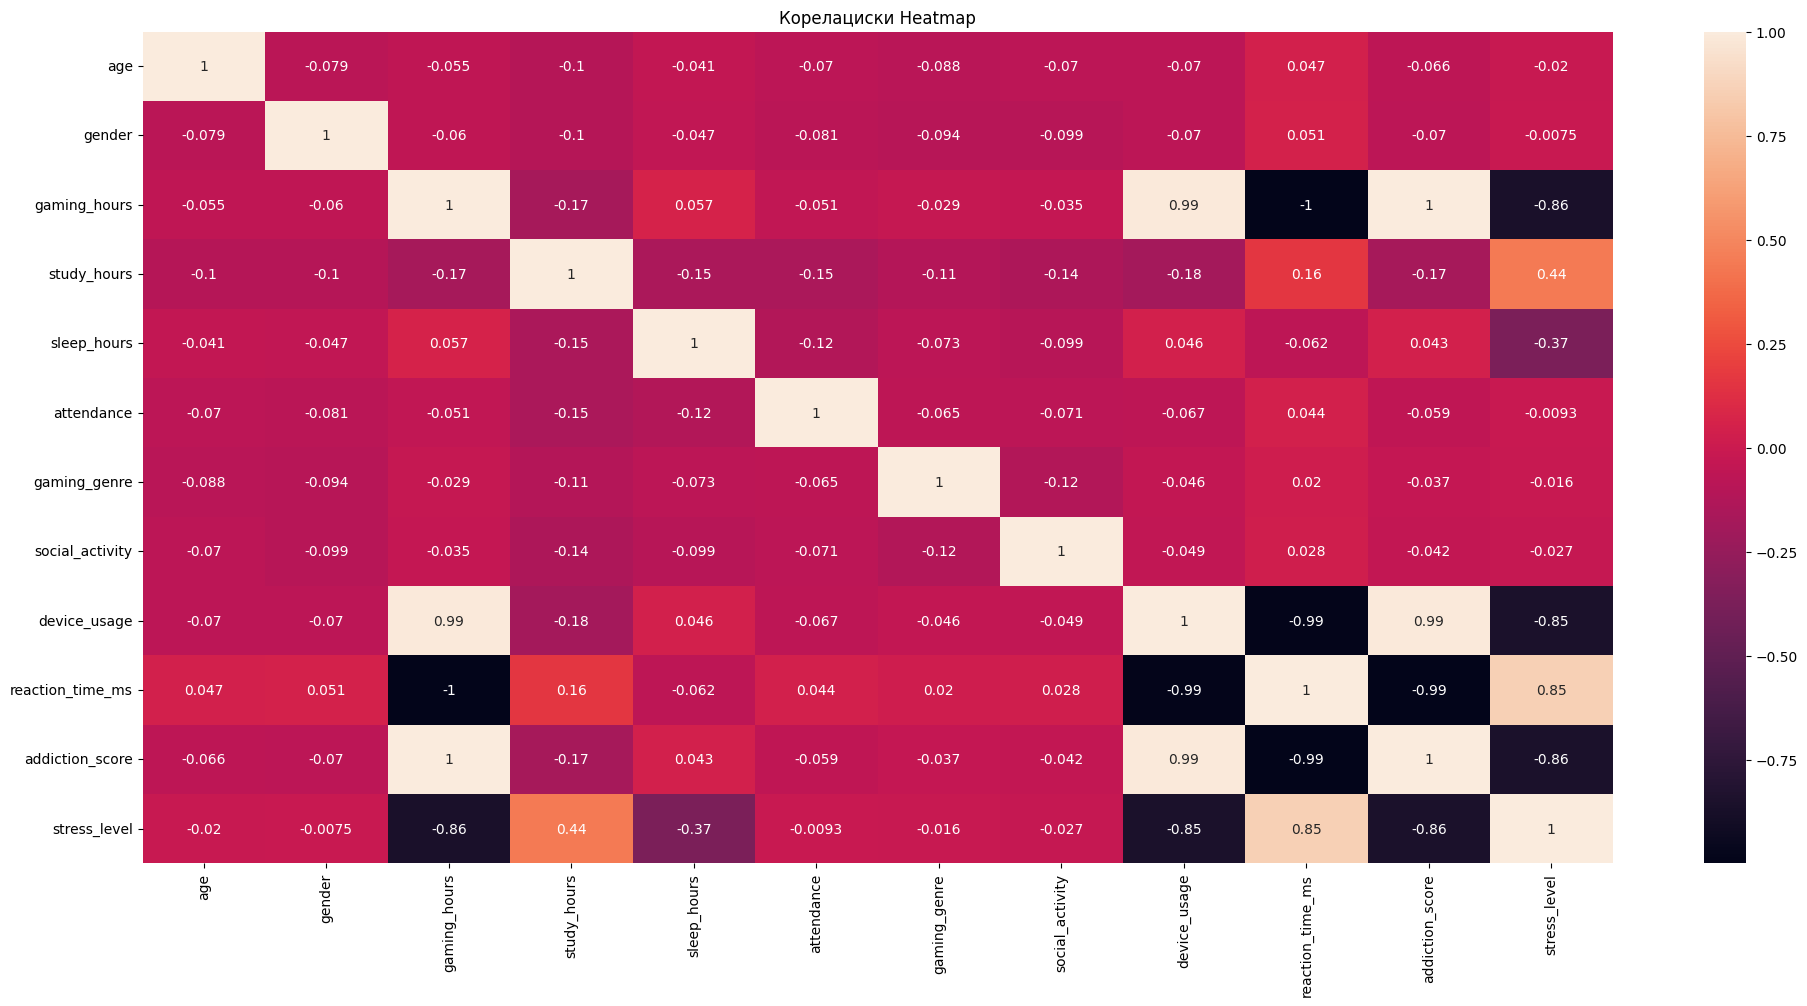

In [44]:
fig = plt.figure(figsize=(20, 10))

correlation_matrix = X.corr()

dataplot = sns.heatmap(correlation_matrix.corr(), annot=True)
plt.tight_layout()
plt.title("Корелациски Heatmap")
plt.show()

In [ ]:
X = X.drop(['device_usage'], axis=1)

In [ ]:
X = X.drop(['reaction_time_ms'], axis=1)

In [ ]:
X = X.drop(['addiction_score'], axis=1)

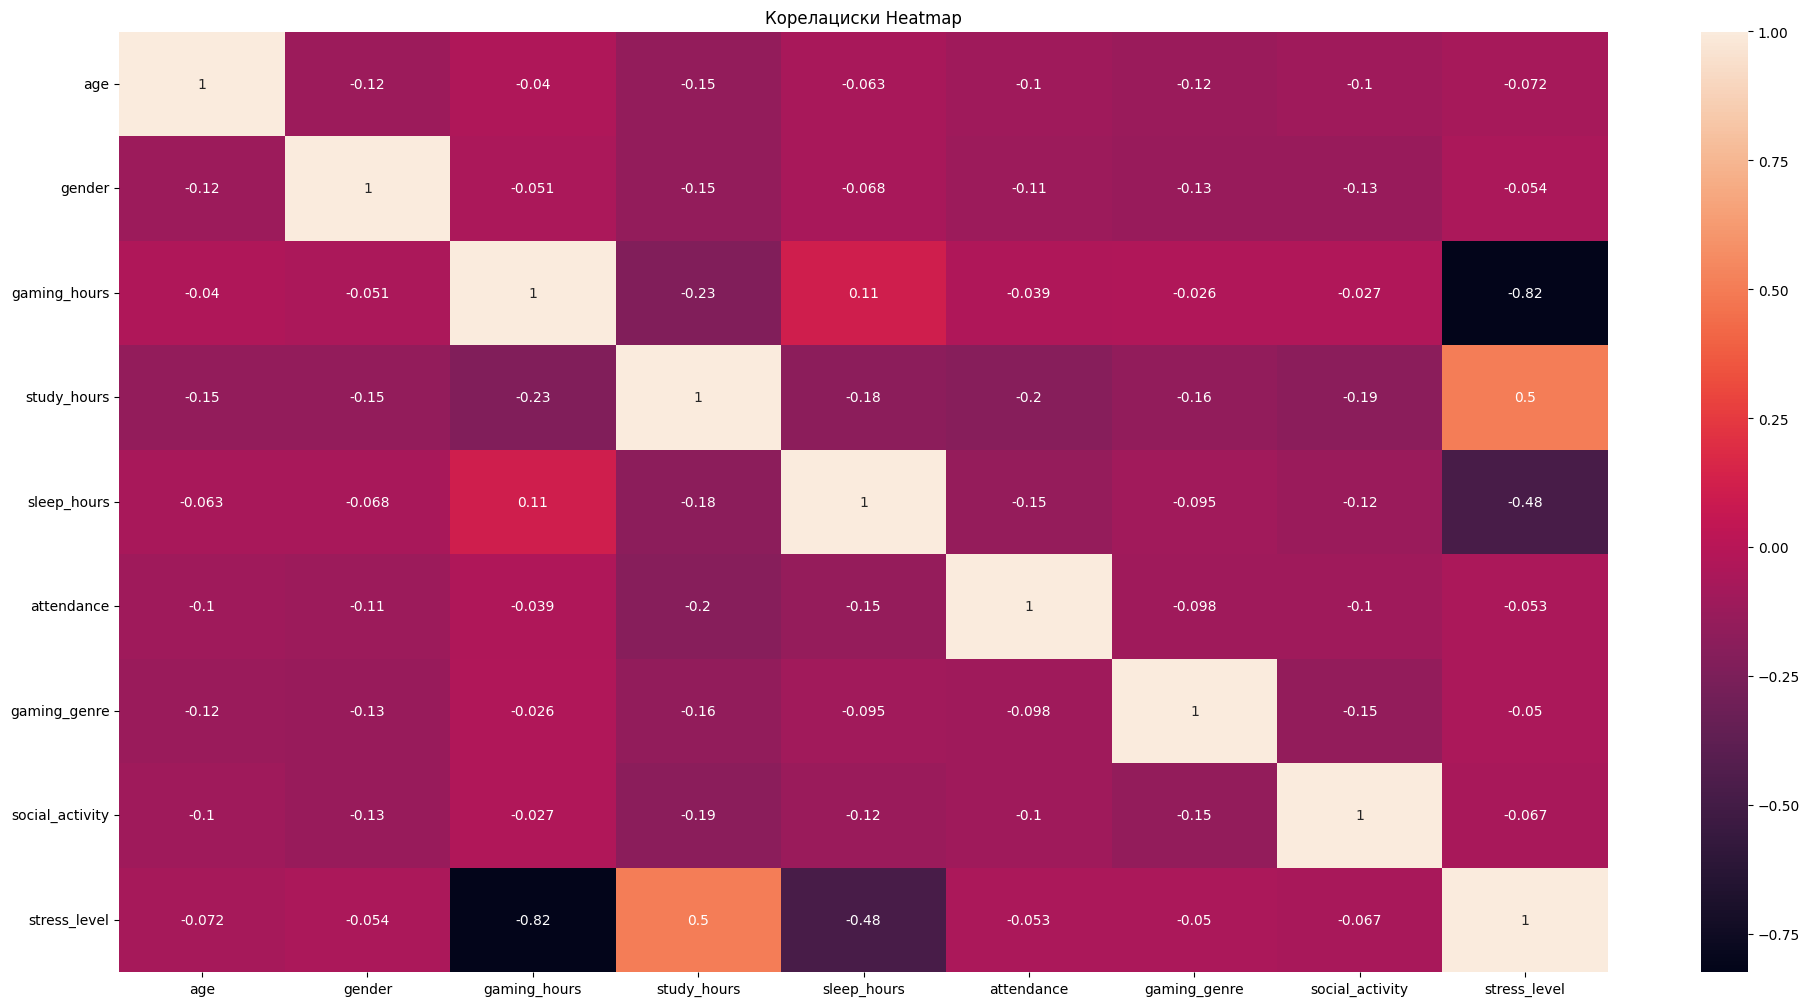

In [ ]:

fig = plt.figure(figsize=(20, 10))

correlation_matrix = X.corr()

dataplot = sns.heatmap(correlation_matrix.corr(), annot=True)
plt.tight_layout()
plt.title("Корелациски Heatmap")
plt.show()

## Тренирање на регресиски модели по таргетот grades
Одлучивме да користиме регресиски (<b>regression</b>) модели за предвидување на оцените на студентите!

In [49]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=1)

In [ ]:
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor

In [ ]:

lin_reg = linear_model.LinearRegression()
lin_reg.fit(X_train, y_train)
score_lin = lin_reg.predict(X_test)


poly2 = PolynomialFeatures(degree = 2)
X_poly2 = poly2.fit_transform(X_train) 

poly2_reg = linear_model.LinearRegression()
poly2_reg.fit(X_poly2, y_train) 

X_poly_test = poly2.transform(X_test) 
score_poly2 = poly2_reg.predict(X_poly_test)


rf_reg = RandomForestRegressor(random_state=1)
rf_reg.fit(X_train, y_train)
score_rf = rf_reg.score(X_test, y_test)


knn_reg = KNeighborsRegressor(n_neighbors=3) 
knn_reg.fit(X_train, y_train)
score_knn = knn_reg.score(X_test, y_test)

dt_reg = DecisionTreeRegressor(random_state=1)
dt_reg.fit(X_train, y_train)
score_reg = dt_reg.score(X_test, y_test)


dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train, y_train)
score_dummy = dummy_reg.score(X_test, y_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:

y_pred_lin = lin_reg.predict(X_test)
y_pred_poly2 = poly2_reg.predict(X_poly_test)
y_pred_dt = dt_reg.predict(X_test)
y_pred_rf = rf_reg.predict(X_test)
y_pred_knn = knn_reg.predict(X_test)
y_pred_dummy = dummy_reg.predict(X_test)


def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return [mae, mse, rmse, r2]


metrics_data = {
    "Linear Regressor": calculate_metrics(y_test, y_pred_lin),
    "Polynomial Degree 2": calculate_metrics(y_test, y_pred_poly2),
    "Decision Tree": calculate_metrics(y_test, y_pred_dt),
    "Random Forest": calculate_metrics(y_test, y_pred_rf),
    "KNN Regressor": calculate_metrics(y_test, y_pred_knn),
    "Dummy Regressor": calculate_metrics(y_test, y_pred_dummy)
}


metrics_df = pd.DataFrame.from_dict(
    metrics_data, 
    orient='index', 
    columns=['MAE', 'MSE', 'RMSE', 'R2']
)

metrics_df

,MAE,MSE,RMSE,R2
Linear Regressor,5.186502,42.863602,6.547030,0.909607
Polynomial Degree 2,4.733908,35.293595,5.940841,0.925571
Decision Tree,6.618617,72.166091,8.495063,0.847813
Random Forest,4.690700,35.619471,5.968205,0.924884
KNN Regressor,7.110981,80.993510,8.999639,0.829197
Dummy Regressor,18.002600,474.193402,21.775982,-0.000002


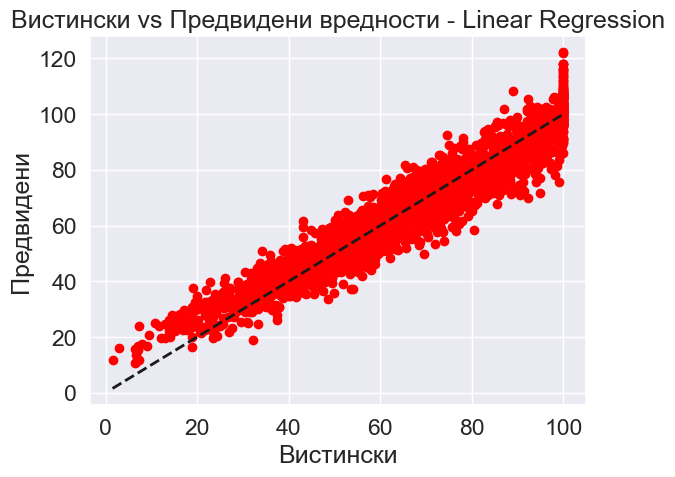

In [ ]:

sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_lin, color='red')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Вистински vs Предвидени вредности - Linear Regression")
plt.show()

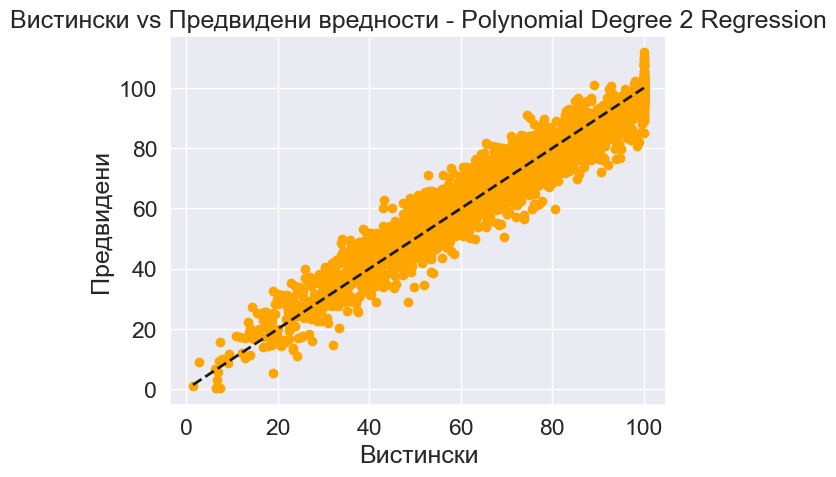

In [ ]:

sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_poly2, color='orange')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Вистински vs Предвидени вредности - Polynomial Degree 2 Regression")
plt.show()

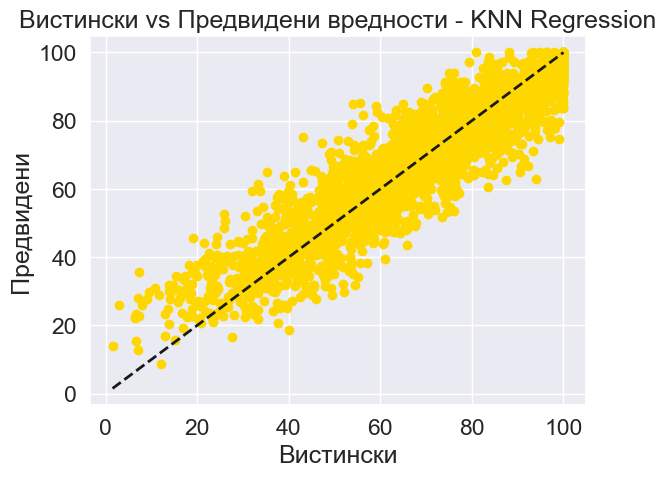

In [ ]:

sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_knn, color='gold')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Вистински vs Предвидени вредности - KNN Regression")
plt.show()

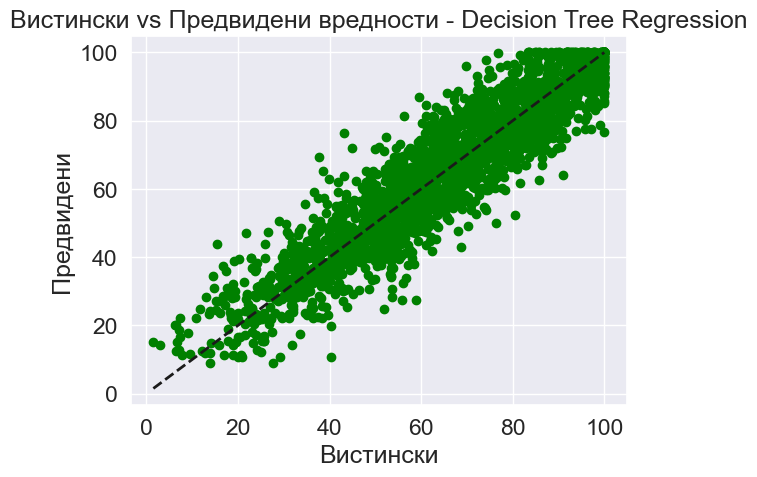

In [ ]:

sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_dt, color='green')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Вистински vs Предвидени вредности - Decision Tree Regression")
plt.show()

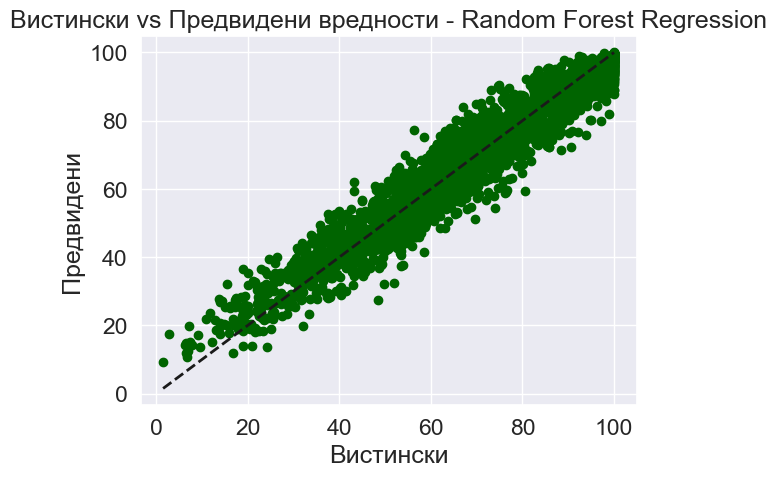

In [ ]:

sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_rf, color='darkgreen')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Вистински vs Предвидени вредности - Random Forest Regression")
plt.show()

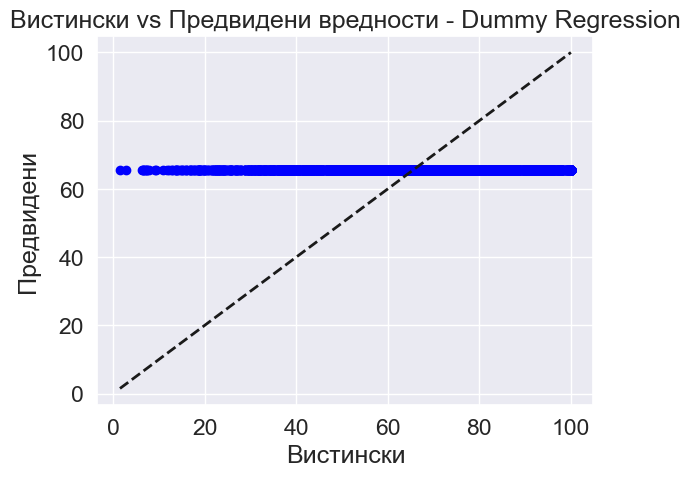

In [ ]:

sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_dummy, color='blue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Вистински vs Предвидени вредности - Dummy Regression")
plt.show()

## Feature selection со SelectKBest
Со цел да видиме кои features најмногу придонесуваат во предвидувањето на оцената, користевме SelectKBest.

In [53]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from numpy import set_printoptions

In [57]:
df_cor = df.drop(['student_id','device_usage','reaction_time_ms','addiction_score'], axis=1) # ги тргаме колоните што не се наоѓаат ни во Х

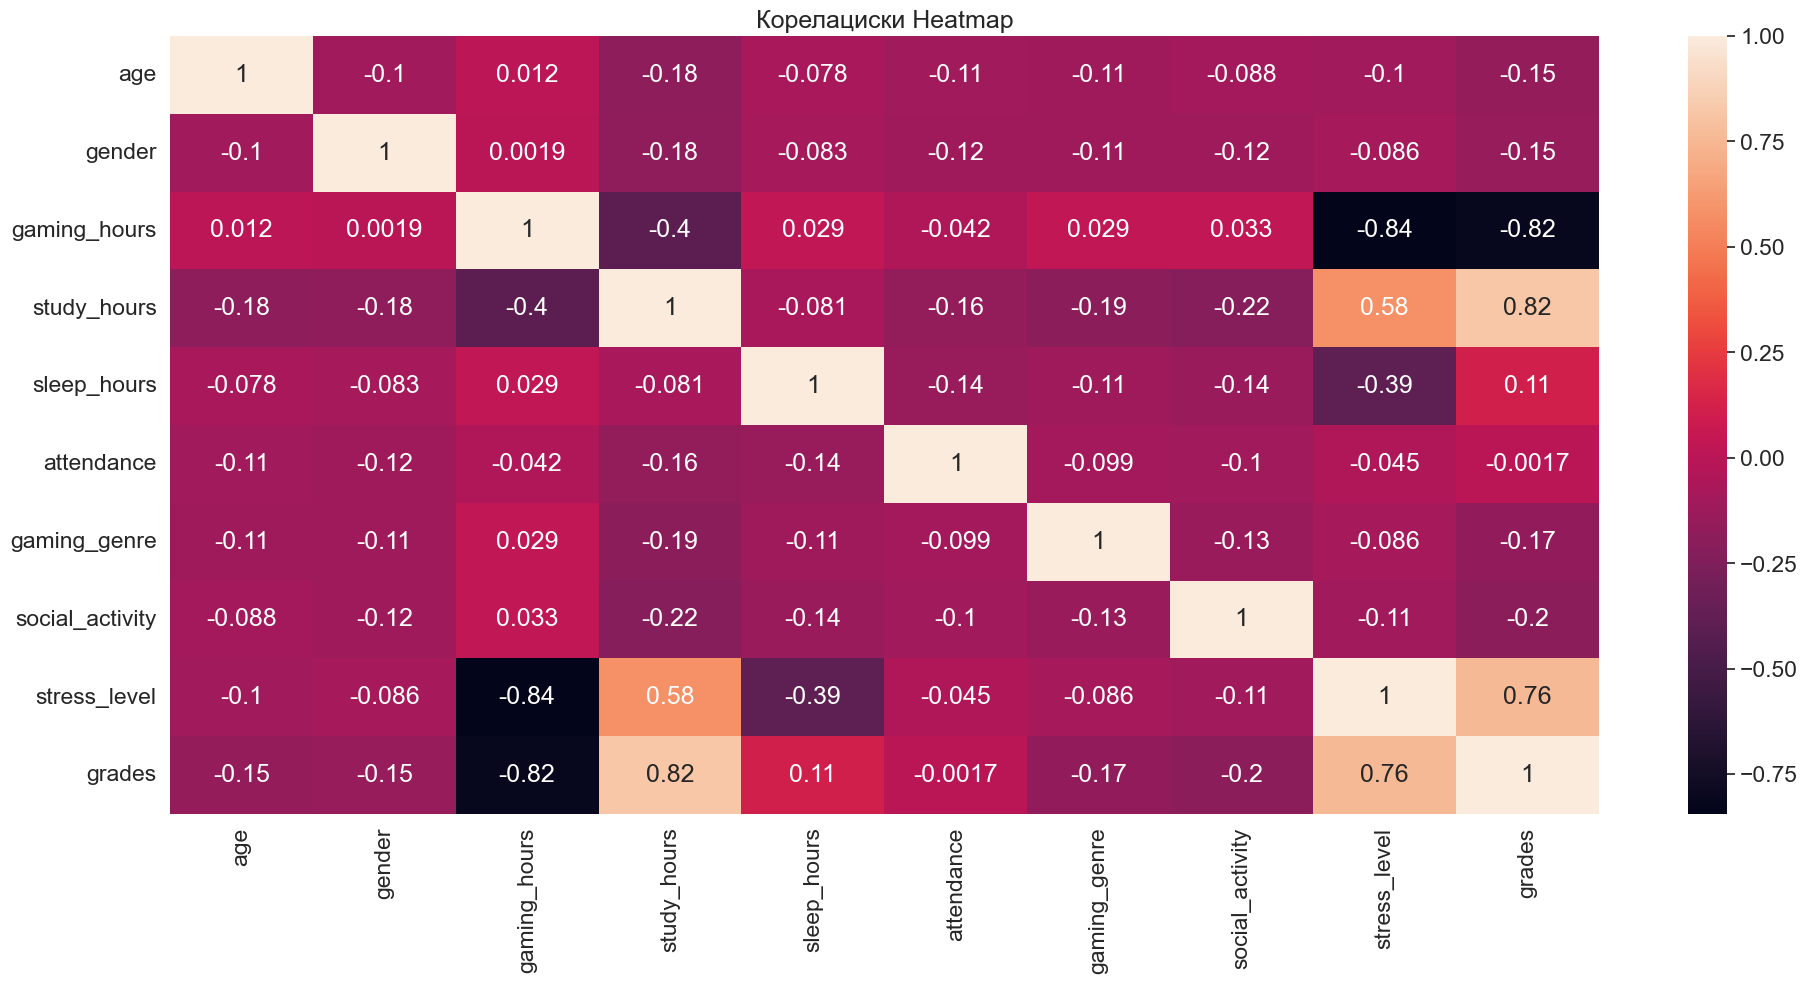

In [58]:
fig = plt.figure(figsize=(20, 10))

correlation_matrix = df_cor.corr()

dataplot = sns.heatmap(correlation_matrix.corr(), annot=True)
plt.tight_layout()
plt.title("Корелациски Heatmap")
plt.show()

Од самата корелациска мапа, доколку ја разгледаме последната редица за grades, може да се одредат features кои најмногу придонесуваат кон предикциите на моделот! Се забележува најголема негативна корелација со gaming_hours додека пак значителни позитивни корелации има со study_hours и stress_level.

In [ ]:

test = SelectKBest(score_func=f_regression, k=5)
fit = test.fit(X_train, y_train)

set_printoptions(precision=1)
print(fit.scores_)
X_new = fit.transform(X_train)
X_new_test = fit.transform(X_test)


print(X_new[0:5])

[2.2e-02 4.0e-01 2.3e+03 6.3e+03 3.9e+02 9.6e+01 2.3e-01 4.4e+00 1.9e+03]
[[-0.   0.4 -1.4  0.8  0.3]
 [ 1.2  1.1 -0.4  1.   1.9]
 [ 0.2  1.5 -1.4  0.8  1.9]
 [ 1.5  0.1 -0.3 -0.6 -1.2]
 [-1.4 -0.7  0.4  1.2  0.3]]


In [ ]:
test.get_support(indices=True)

array([2, 3, 4, 5, 8])

In [ ]:
X.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 7866 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              7866 non-null   float64
 1   gender           7866 non-null   float64
 2   gaming_hours     7866 non-null   float64
 3   study_hours      7866 non-null   float64
 4   sleep_hours      7866 non-null   float64
 5   attendance       7866 non-null   float64
 6   gaming_genre     7866 non-null   float64
 7   social_activity  7866 non-null   float64
 8   stress_level     7866 non-null   float64
dtypes: float64(9)
memory usage: 614.5 KB


### Oдвоените features се следните:

2 - gaming_hours  
3 - study_hours  
4 - sleep_hours  
5 - attendance  
8 - stress_level

In [ ]:
# 1. Linear Regressor
lin_reg = linear_model.LinearRegression()
lin_reg.fit(X_new, y_train)
score_lin = lin_reg.predict(X_new_test)

# 2. Polynomial Regressor Degree 2
poly2 = PolynomialFeatures(degree = 2)
X_poly2 = poly2.fit_transform(X_new) 

poly2_reg = linear_model.LinearRegression()
poly2_reg.fit(X_poly2, y_train) 

X_poly_test = poly2.transform(X_new_test) 
score_poly2 = poly2_reg.predict(X_poly_test)

# 3. Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=1)
rf_reg.fit(X_new, y_train)
score_rf = rf_reg.score(X_new_test, y_test)

# 4. KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=3) 
knn_reg.fit(X_new, y_train)
score_knn = knn_reg.score(X_new_test, y_test)

# 5. Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=1)
dt_reg.fit(X_new, y_train)
score_reg = dt_reg.score(X_new_test, y_test)

# 6. Dummy Regressor
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_new, y_train)
score_dummy = dummy_reg.score(X_new_test, y_test)

In [65]:
y_pred_lin = lin_reg.predict(X_new_test)
y_pred_poly2 = poly2_reg.predict(X_poly_test)
y_pred_dt = dt_reg.predict(X_new_test)
y_pred_rf = rf_reg.predict(X_new_test)
y_pred_knn = knn_reg.predict(X_new_test)
y_pred_dummy = dummy_reg.predict(X_new_test)

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return [mae, mse, rmse, r2]


metrics_data = {
    "Linear Regressor": calculate_metrics(y_test, y_pred_lin),
    "Polynomial Degree 2": calculate_metrics(y_test, y_pred_poly2),
    "Decision Tree": calculate_metrics(y_test, y_pred_dt),
    "Random Forest": calculate_metrics(y_test, y_pred_rf),
    "KNN Regressor": calculate_metrics(y_test, y_pred_knn),
    "Dummy Regressor": calculate_metrics(y_test, y_pred_dummy)
}

metrics_df = pd.DataFrame.from_dict(
    metrics_data, 
    orient='index', 
    columns=['MAE', 'MSE', 'RMSE', 'R2']
)

metrics_df

,MAE,MSE,RMSE,R2
Linear Regressor,5.185186,42.850295,6.546014,0.909635
Polynomial Degree 2,4.726990,35.259469,5.937968,0.925643
Decision Tree,6.454141,69.642796,8.345226,0.853134
Random Forest,4.677686,35.472498,5.955879,0.925194
KNN Regressor,5.248911,44.289243,6.655016,0.906601
Dummy Regressor,18.002600,474.193402,21.775982,-0.000002


Се забележуваат намалени грешки, особено за Random Forest што повторно се покажа како модел со најмала грешка!

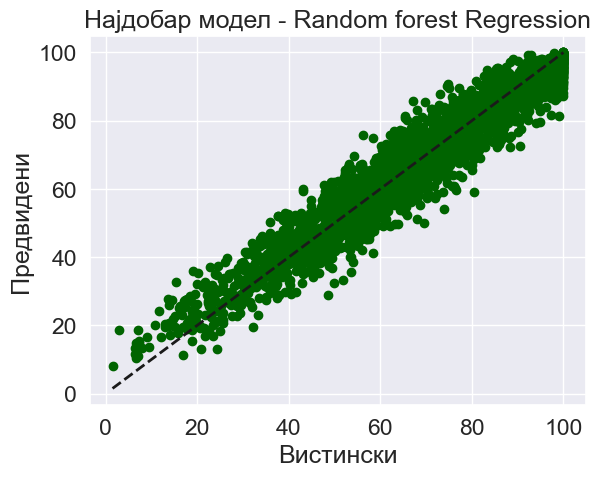

In [66]:
# график за Random Forest Regression - моделот со најмала грешка
sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_rf, color='darkgreen')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Најдобар модел - Random forest Regression")
plt.show()

## Hyperoptimization
Извршивме хипероптимизација на параметрите за Random Forest регресискиот модел, како најдобар.
Најпрвин извршивме Randomized Search Cross Validation.

### Randomized Search

In [ ]:
# cross validation за оптимизација на параметрите
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_validate
np.random.seed(seed=1)

scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2']



n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1000, num = 10)]
max_features = ['auto', 'sqrt', 2, 3, 5, 6, 8, 'None']
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
min_samples_split = [1, 2, 5, 8, 10]
min_samples_leaf = [1, 2, 3, 4, 5]
bootstrap = [True, False]

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
random_search = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

clf = RandomForestRegressor()
model = RandomizedSearchCV(estimator = clf, 
                           param_distributions = random_search, 
                           n_iter = 100, 
                           cv = 3, verbose= 5, random_state= 1, 
                           n_jobs = -1)

model.fit(X_train,y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'max_features': ['auto', 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versio

In [ ]:
y_pred_rf = model.predict(X_test)

In [ ]:

metrics_data = {
    "Random Forest": calculate_metrics(y_test, y_pred_rf)
}

metrics_df = pd.DataFrame.from_dict(
    metrics_data, 
    orient='index', 
    columns=['MAE', 'MSE', 'RMSE', 'R2']
)

metrics_df

,MAE,MSE,RMSE,R2
Random Forest,4.651797,34.809712,5.899976,0.926592


Грешката дополнително се намали со Random Search хипероптимизација!

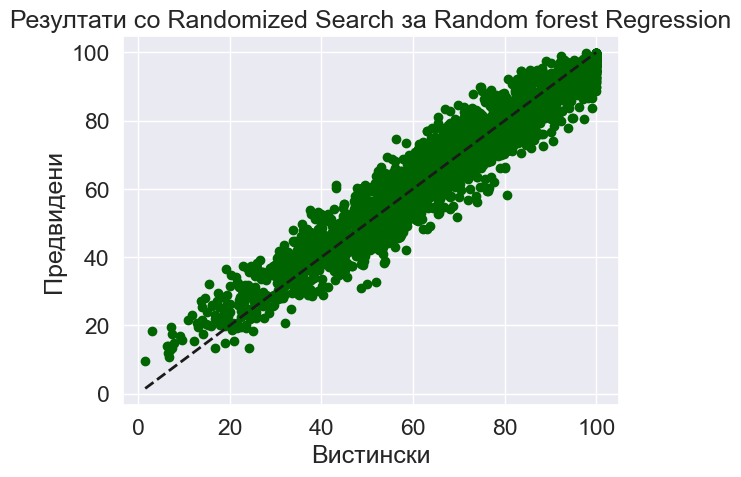

In [ ]:

sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_rf, color='darkgreen')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Резултати со Randomized Search за Random forest Regression")
plt.show()

### Optuna

In [ ]:
 import optuna
 from sklearn.model_selection import cross_val_score

 def objective(trial):
     n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
     max_depth = trial.suggest_int('max_depth', 10, 50, step=10)
     min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
     min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    
     model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                   min_samples_split=min_samples_split, 
                                   min_samples_leaf=min_samples_leaf, random_state=42)
    
     score = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_squared_error').mean()
    
     return -score 

 study = optuna.create_study(direction='minimize')
 study.optimize(objective, n_trials=6)

 best_params = study.best_params
 best_rf_optuna = RandomForestRegressor(**best_params, random_state=42)
 best_rf_optuna.fit(X_train, y_train)

 y_pred_optuna = best_rf_optuna.predict(X_test)
 mse_optuna = mean_squared_error(y_test, y_pred_optuna)
 rmse_optuna = np.sqrt(mse_optuna)

 print(f"Најдобри параметри (Optuna): {best_params}")
 print(f"Тест RMSE (Optuna): {rmse_optuna:.4f}")


[I 2026-05-25 14:00:19,380] A new study created in memory with name: no-name-5f383e93-8c2c-4a3d-8621-c3634e2174f3
[I 2026-05-25 14:00:35,014] Trial 0 finished with value: 33.96940253839219 and parameters: {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 0 with value: 33.96940253839219.
[I 2026-05-25 14:00:50,469] Trial 1 finished with value: 34.104980017142644 and parameters: {'n_estimators': 200, 'max_depth': 40, 'min_samples_split': 8, 'min_samples_leaf': 2}. Best is trial 0 with value: 33.96940253839219.
[I 2026-05-25 14:00:54,740] Trial 2 finished with value: 34.463376518471016 and parameters: {'n_estimators': 50, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: 33.96940253839219.
[I 2026-05-25 14:01:15,315] Trial 3 finished with value: 34.14720673164306 and parameters: {'n_estimators': 250, 'max_depth': 40, 'min_samples_split': 7, 'min_samples_leaf': 1}. Best is trial 0 with value: 33.9

Најдобри параметри (Optuna): {'n_estimators': 200, 'max_depth': 30, 'min_samples_split': 6, 'min_samples_leaf': 3}
Тест RMSE (Optuna): 5.9224


In [ ]:

metrics_data = {
    "Random Forest": calculate_metrics(y_test, y_pred_optuna)
}

metrics_df = pd.DataFrame.from_dict(
    metrics_data, 
    orient='index', 
    columns=['MAE', 'MSE', 'RMSE', 'R2']
)

metrics_df

,MAE,MSE,RMSE,R2
Random Forest,4.648555,35.074387,5.922363,0.926033


Optuna малку повеќе ја намалува грешката во однос на Random Search!

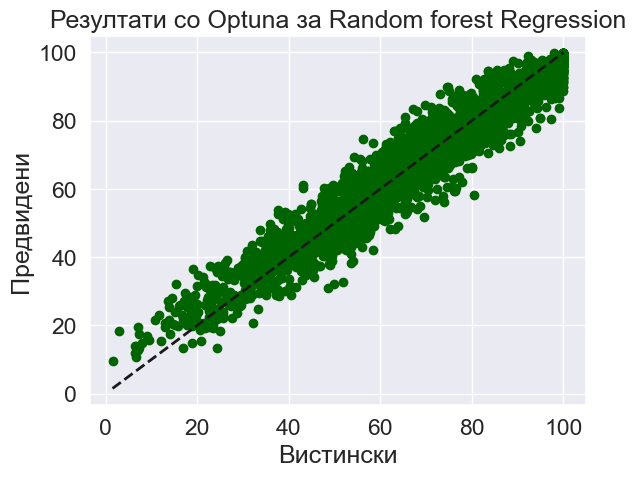

In [74]:
# график за Random Forest Regression со Optuna
sns.set_theme(font_scale=1.5)
plt.scatter(y_test, y_pred_rf, color='darkgreen')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.xlabel('Вистински')
plt.ylabel('Предвидени')
plt.title("Резултати со Optuna за Random forest Regression")
plt.show()